# Train nhánh rPPG — CAN (Convolutional Attention Network) trên FF++ C23

**Kiến trúc:** Dựa trên **DeepPhys / DeepFakesON-Phys** — dual-branch CAN:
- **Nhánh Appearance:** xử lý raw face frame → tạo attention mask
- **Nhánh Motion:** xử lý **normalized frame difference** → dùng attention mask từ Appearance để tập trung vào vùng da

**Cải tiến so với DeepFakesON-Phys gốc:**
- Backbone sâu hơn (6 conv blocks thay vì 4)
- Squeeze-Excitation channel attention
- Temporal aggregation bằng attention pooling (thay vì trung bình đơn giản)
- MixUp + EMA + Label Smoothing + Mixed Precision

**Dữ liệu:** Dùng lại cache rPPG cũ (`ffpp_c23_rppg_cache`) — tính frame difference **on-the-fly**, KHÔNG cần cache mới.

---

### ⚠️ Input cần add trên Kaggle:
1. `thinhphan272/ffpp-c23-rppg-cache` — cache frame khuôn mặt đã crop
2. `peiyuanzhang/ff-split` — file split train/val/test


---
### 🔧 Bản vá (v3_improved) — dựa lại trên cấu hình GỐC đã cho AUC 90% (không dựa trên bản v2_fixed)

**Nhận lỗi:** bản vá trước (bỏ `WeightedRandomSampler` → dùng `pos_weight`) làm kết quả TỆ ĐI
(AUC 90.05%→87.54%, EER 18.04%→21.43%, cả 4 method đều giảm). Nguyên nhân: model dùng nhiều lớp
`BatchNorm2d` — bỏ sampler khiến nhiều batch có rất ít/không có video Real, làm nhiễu thống kê
BatchNorm giữa các batch. `pos_weight` chỉ sửa trọng số loss, không sửa được vấn đề này.

**Bản vá lần này** quay lại đúng cấu hình gốc (đã chứng minh hiệu quả) + 3 cải tiến an toàn:
1. Khôi phục `WeightedRandomSampler`, khôi phục `BATCH_SIZE=16`.
2. **Nâng cấp sampler**: cân bằng theo cả class lẫn từng phương pháp fake, lấy mẫu nhiều hơn cho
   NeuralTextures/Face2Face/FaceSwap (đang yếu) so với Deepfakes (đã rất tốt) — nhắm thẳng vào
   điểm yếu đã xác định qua breakdown.
3. Tăng `EPOCHS` 40→60 (đường cong AUC bản gốc vẫn đang đi lên ở epoch cuối, chưa bão hoà).
4. Thêm `acc_at_eer` (không thay đổi cách train, chỉ bổ sung số liệu báo cáo).

**Về mục tiêu "mọi thứ trên 90%":** với NeuralTextures hiện chỉ 0.74 AUC, việc đẩy method này
qua 0.90 là mục tiêu nhiều tham vọng — sampler nặng hơn cho method khó có thể giúp cải thiện
đáng kể, nhưng khó đảm bảo chắc chắn vượt 0.90 riêng cho NeuralTextures. Sau khi chạy xong, nhìn
bảng breakdown mới để đánh giá mức cải thiện thực tế trước khi quyết định bước tiếp theo (có thể
cần kiến trúc phức tạp hơn cho riêng nhánh này nếu vẫn chưa đủ).
---


## 1. Cấu hình & Import

In [1]:
import os, glob, time, random, copy, json, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
SPLIT_JSON_DIR = "/kaggle/input/datasets/peiyuanzhang/ff-split"
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")

assert os.path.isdir(CACHE_DIR), f"Không tìm thấy CACHE_DIR: {CACHE_DIR}"
assert os.path.exists(MANIFEST_CSV), f"Không tìm thấy manifest: {MANIFEST_CSV}"

# ==================== THAM SỐ ====================
CAN_IMG_SIZE     = 72       # CAN không cần ảnh lớn
CLIP_LEN_TRAIN   = 32      # số cặp frame liên tiếp mỗi clip khi train
CLIP_LEN_EVAL    = 64      # dài hơn khi eval để ổn định hơn
MIN_FRAMES       = 50      # video phải có ít nhất 50 frame

BATCH_SIZE       = 16      # mỗi sample là 1 clip gồm nhiều frame pairs
EPOCHS           = 60      # tăng từ 40: val_auc bản trước vẫn đang tăng ở epoch 38-40, chưa bão hoà
WARMUP_EPOCHS    = 3
LR               = 2e-4
WEIGHT_DECAY     = 1e-2
DROPOUT          = 0.3

MIXUP_ALPHA      = 0.2
LABEL_SMOOTH_EPS = 0.05
EMA_DECAY        = 0.999
DIFF_EPS         = 1.0     # epsilon cho normalized frame difference

PATIENCE   = 14            # tăng tương ứng để không dừng sớm khi train lâu hơn
SEED       = 42
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR    = "/kaggle/working/rppg_can_branch"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Device:", DEVICE)
print("Cache:", CACHE_DIR)


Device: cuda
Cache: /kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache


## 2. Đọc manifest & chia tập

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest['out_dir'] = manifest['out_dir'].str.replace(
    '/kaggle/working/ffpp_c23_rppg_cache', CACHE_DIR, regex=False)

# Lọc video đủ frame
manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists", "partial"]) & (manifest["n_frames"] >= MIN_FRAMES)
].reset_index(drop=True)

print(f"Tổng video đủ điều kiện: {len(manifest_ok)} / {len(manifest)}")
print(manifest_ok.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"}))

train_df = manifest_ok[manifest_ok.split == "train"].reset_index(drop=True)
val_df   = manifest_ok[manifest_ok.split == "val"].reset_index(drop=True)
test_df  = manifest_ok[manifest_ok.split == "test"].reset_index(drop=True)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Tổng video đủ điều kiện: 5000 / 5000
label  real  fake
split            
test    140   560
train   720  2880
val     140   560

Train: 3600 | Val: 700 | Test: 700


## 3. Dataset — load frame pairs + compute frame difference on-the-fly

Mỗi sample = 1 clip gồm `CLIP_LEN` cặp frame liên tiếp.
Với mỗi cặp `(frame_t, frame_{t-1})`:
- **Appearance input:** `frame_t` (raw, chuẩn hóa về [0,1])
- **Motion input:** `D(t) = (F_t - F_{t-1}) / (F_t + F_{t-1} + ε)` (normalized frame difference)


In [3]:
def load_and_resize(path, size=CAN_IMG_SIZE):
    """Load ảnh BGR → RGB, resize về size×size, trả về float32 [0, 255]."""
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32)


def compute_normalized_diff(curr, prev, eps=DIFF_EPS):
    """Normalized frame difference theo DeepPhys: D = (F_t - F_{t-1}) / (F_t + F_{t-1} + eps)."""
    return (curr - prev) / (curr + prev + eps)


class CANTrainDataset(Dataset):
    """Dataset cho training: trả về clip gồm nhiều cặp frame liên tiếp."""
    def __init__(self, df, clip_len=CLIP_LEN_TRAIN, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        frame_paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n_frames = len(frame_paths)

        # Cần ít nhất clip_len + 1 frame (để tính clip_len differences)
        need = self.clip_len + 1
        if n_frames >= need:
            start = random.randint(0, n_frames - need)
        else:
            start = 0

        # Load các frame cần thiết
        appearances = []  # raw frames normalized to [0, 1]
        motions = []      # normalized frame differences

        prev_img = None
        for i in range(min(need, n_frames)):
            fi = min(start + i, n_frames - 1)
            img = load_and_resize(frame_paths[fi], self.img_size)

            if prev_img is not None:
                diff = compute_normalized_diff(img, prev_img)
                # Chuẩn hóa về [0, 1] cho raw frame
                appearances.append(img / 255.0)
                motions.append(diff)

            prev_img = img

        # Padding nếu thiếu
        while len(appearances) < self.clip_len:
            appearances.append(appearances[-1] if appearances else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            motions.append(motions[-1] if motions else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        appearances = appearances[:self.clip_len]
        motions = motions[:self.clip_len]

        # Stack: (clip_len, H, W, 3) → (clip_len, 3, H, W) cho PyTorch
        app_tensor = torch.from_numpy(np.stack(appearances)).permute(0, 3, 1, 2).float()
        mot_tensor = torch.from_numpy(np.stack(motions)).permute(0, 3, 1, 2).float()

        # Data augmentation
        if random.random() < 0.5:
            app_tensor = torch.flip(app_tensor, dims=[3])  # horizontal flip
            mot_tensor = torch.flip(mot_tensor, dims=[3])
        if random.random() < 0.3:
            # Color jitter nhẹ cho appearance
            jitter = torch.empty(1, 3, 1, 1).uniform_(0.9, 1.1)
            app_tensor = (app_tensor * jitter).clamp(0, 1)
        if random.random() < 0.2:
            # Gaussian noise nhẹ cho motion
            noise = torch.randn_like(mot_tensor) * 0.01
            mot_tensor = mot_tensor + noise

        label = torch.tensor(row.label, dtype=torch.float32)
        return app_tensor, mot_tensor, label


class CANEvalDataset(Dataset):
    """Dataset cho eval: trả về clip dài hơn + video_id."""
    def __init__(self, df, clip_len=CLIP_LEN_EVAL, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        frame_paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n_frames = len(frame_paths)

        # Lấy clip ở giữa video
        need = self.clip_len + 1
        start = max(0, (n_frames - need) // 2)

        appearances = []
        motions = []
        prev_img = None
        for i in range(min(need, n_frames)):
            fi = min(start + i, n_frames - 1)
            img = load_and_resize(frame_paths[fi], self.img_size)
            if prev_img is not None:
                diff = compute_normalized_diff(img, prev_img)
                appearances.append(img / 255.0)
                motions.append(diff)
            prev_img = img

        while len(appearances) < self.clip_len:
            appearances.append(appearances[-1] if appearances else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            motions.append(motions[-1] if motions else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        appearances = appearances[:self.clip_len]
        motions = motions[:self.clip_len]

        app_tensor = torch.from_numpy(np.stack(appearances)).permute(0, 3, 1, 2).float()
        mot_tensor = torch.from_numpy(np.stack(motions)).permute(0, 3, 1, 2).float()
        label = torch.tensor(row.label, dtype=torch.float32)
        return app_tensor, mot_tensor, label, row.video_id


# Tạo DataLoader
train_ds = CANTrainDataset(train_df)
val_ds   = CANEvalDataset(val_df)
test_ds  = CANEvalDataset(test_df)

class_counts = train_df["label"].value_counts().to_dict()

# SỬA: cân bằng theo CẢ class (Real/Fake) LẪN từng phương pháp fake -- dựa trên breakdown thực
# nghiệm trước (NeuralTextures AUC=0.74, Face2Face/FaceSwap AUC=0.89, Deepfakes AUC=0.99) để lấy
# mẫu nhiều hơn cho các phương pháp đang yếu, giúp mô hình học kỹ hơn đúng chỗ hiện đang kém.
METHOD_DIFFICULTY_WEIGHT = {
    "NeuralTextures": 2.0,   # yếu nhất (AUC 0.74) -> lấy mẫu gấp đôi
    "Face2Face":      1.4,
    "FaceSwap":        1.4,
    "Deepfakes":       1.0,   # đã rất tốt (AUC 0.99) -> giữ tần suất gốc
}

def sample_weight(row):
    if row["label"] == 0:
        return 1.0 / class_counts[0]
    base = 1.0 / class_counts[1]
    mult = METHOD_DIFFICULTY_WEIGHT.get(row.get("method", ""), 1.0)
    return base * mult

sample_weights = train_df.apply(sample_weight, axis=1).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
print("Số lượng theo lớp (train):", class_counts)
print("Trọng số lấy mẫu theo method (fake):", METHOD_DIFFICULTY_WEIGHT)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} videos | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Mỗi train clip: {CLIP_LEN_TRAIN} frame pairs | Eval clip: {CLIP_LEN_EVAL} frame pairs")


Số lượng theo lớp (train): {1: 2880, 0: 720}
Trọng số lấy mẫu theo method (fake): {'NeuralTextures': 2.0, 'Face2Face': 1.4, 'FaceSwap': 1.4, 'Deepfakes': 1.0}
Train: 3600 videos | Val: 700 | Test: 700
Mỗi train clip: 32 frame pairs | Eval clip: 64 frame pairs


## 4. Mô hình — CAN Dual-Branch (cải tiến DeepPhys)

Kiến trúc 2 nhánh song song:
- **Appearance Branch:** CNN xử lý raw frame → tạo spatial attention masks
- **Motion Branch:** CNN xử lý frame difference, nhân với attention masks từ Appearance
- **Temporal Aggregation:** Attention pooling gộp predictions từ nhiều frame pairs thành 1 video-level prediction


In [4]:
class SqueezeExcitation(nn.Module):
    """Channel attention — tự động học trọng số cho từng kênh."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class ConvBlock(nn.Module):
    """2 lớp conv + BN + ReLU + optional SE."""
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
    def forward(self, x):
        return self.se(self.conv(x))


class AttentionMask(nn.Module):
    """Tạo spatial attention mask từ feature map."""
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 1, kernel_size=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.conv(x)


class TemporalAttentionPool(nn.Module):
    """Gộp predictions từ nhiều frame pairs bằng attention pooling."""
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 4), nn.ReLU(),
            nn.Linear(dim // 4, 1),
        )
    def forward(self, x):
        # x: (B, T, dim)
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)


class DeepPhysCAN(nn.Module):
    """CAN Dual-Branch cải tiến từ DeepPhys/DeepFakesON-Phys.
    
    Appearance branch tạo attention masks hướng dẫn Motion branch
    tập trung vào vùng da có tín hiệu sinh học.
    """
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        
        # ===== Appearance Branch (raw frame → attention masks) =====
        self.app_block1 = ConvBlock(3, 32)
        self.app_block2 = ConvBlock(32, 64)
        self.app_block3 = ConvBlock(64, 128, use_se=True)
        
        self.att_mask1 = AttentionMask(32)
        self.att_mask2 = AttentionMask(64)
        self.att_mask3 = AttentionMask(128)
        
        # ===== Motion Branch (frame diff → features) =====
        self.mot_block1 = ConvBlock(3, 32)
        self.mot_block2 = ConvBlock(32, 64)
        self.mot_block3 = ConvBlock(64, 128, use_se=True)
        
        self.pool = nn.AvgPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # ===== Per-frame feature head =====
        self.frame_feat = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout),
        )
        
        # ===== Temporal aggregation =====
        self.temporal_pool = TemporalAttentionPool(128)
        
        # ===== Classifier =====
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        
        self.embed_dim = 128  # for fusion model later

    def forward_single_pair(self, appearance, motion):
        """Xử lý 1 cặp frame (appearance + motion) → feature vector 128-d."""
        # Appearance branch → attention masks
        a1 = self.app_block1(appearance)
        mask1 = self.att_mask1(a1)
        a1 = self.pool(a1)
        
        a2 = self.app_block2(a1)
        mask2 = self.att_mask2(a2)
        a2 = self.pool(a2)
        
        a3 = self.app_block3(a2)
        mask3 = self.att_mask3(a3)
        
        # Motion branch, guided by attention masks
        m1 = self.mot_block1(motion)
        m1 = m1 * mask1           # attention-guided
        m1 = self.pool(m1)
        
        m2 = self.mot_block2(m1)
        m2 = m2 * mask2           # attention-guided
        m2 = self.pool(m2)
        
        m3 = self.mot_block3(m2)
        m3 = m3 * mask3           # attention-guided
        
        # Global average pooling → feature vector
        feat = self.gap(m3).flatten(1)
        feat = self.frame_feat(feat)
        return feat
    
    def forward_features(self, app_clip, mot_clip):
        """Xử lý toàn bộ clip → feature vector 128-d (cho fusion model).
        app_clip: (B, T, 3, H, W), mot_clip: (B, T, 3, H, W)
        """
        B, T = app_clip.shape[:2]
        # Reshape để xử lý tất cả frame pairs cùng lúc
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        
        frame_feats = self.forward_single_pair(app_flat, mot_flat)  # (B*T, 128)
        frame_feats = frame_feats.reshape(B, T, -1)                # (B, T, 128)
        
        # Temporal attention pooling
        video_feat = self.temporal_pool(frame_feats)                # (B, 128)
        return video_feat
    
    def forward(self, app_clip, mot_clip):
        """Forward pass: clip → logit."""
        video_feat = self.forward_features(app_clip, mot_clip)
        return self.classifier(video_feat).squeeze(-1)


model = DeepPhysCAN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"DeepPhysCAN parameters: {n_params/1e6:.2f}M | embed_dim={model.embed_dim}")


DeepPhysCAN parameters: 0.62M | embed_dim=128


## 5. Hàm tính metric

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_at_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    return {
        "acc": acc, "auc": auc_val, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer,
        "acc_at_eer": acc_at_eer,
    }


## 6. MixUp / Label Smoothing / EMA

In [6]:
def mixup_batch(app, mot, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return app, mot, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(app.size(0), device=app.device)
    app_mix = lam * app + (1 - lam) * app[idx]
    mot_mix = lam * mot + (1 - lam) * mot[idx]
    return app_mix, mot_mix, labels, labels[idx], lam


def smooth_labels(labels, eps=LABEL_SMOOTH_EPS):
    return labels * (1 - eps) + 0.5 * eps


class ModelEma:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema_model = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema_model.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, ema_v in self.ema_model.state_dict().items():
            model_v = msd[k].detach()
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(model_v, alpha=1 - self.decay)
            else:
                ema_v.copy_(model_v)


## 7. Vòng lặp huấn luyện

In [7]:
@torch.no_grad()
def evaluate(eval_model, loader, criterion):
    eval_model.eval()
    y_true, y_score, losses = [], [], []
    for app_clip, mot_clip, label, _vid in loader:
        app_clip = app_clip.to(DEVICE)
        mot_clip = mot_clip.to(DEVICE)
        label = label.to(DEVICE)
        logits = eval_model(app_clip, mot_clip)
        loss = criterion(logits, label)
        losses.append(loss.item())
        y_score.append(torch.sigmoid(logits).item())
        y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics


criterion = nn.BCEWithLogitsLoss()
ema = ModelEma(model, decay=EMA_DECAY)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=WARMUP_EPOCHS / EPOCHS,
    anneal_strategy="cos",
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

BEST_PATH = os.path.join(OUT_DIR, "rppg_can_best.pth")
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [],
           "val_eer": [], "used_ema": [], "lr": []}
best_val_auc = -1
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, n_batches = 0.0, 0
    t0 = time.time()

    for app_clip, mot_clip, label in train_loader:
        app_clip = app_clip.to(DEVICE)
        mot_clip = mot_clip.to(DEVICE)
        label = label.to(DEVICE)

        app_mix, mot_mix, y_a, y_b, lam = mixup_batch(app_clip, mot_clip, label)
        y_a, y_b = smooth_labels(y_a), smooth_labels(y_b)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(app_mix, mot_mix)
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)

        running_loss += loss.item()
        n_batches += 1

    train_loss = running_loss / max(n_batches, 1)
    val_metrics_raw = evaluate(model, val_loader, criterion)
    val_metrics_ema = evaluate(ema.ema_model, val_loader, criterion)
    use_ema = val_metrics_ema["auc"] >= val_metrics_raw["auc"]
    val_metrics = val_metrics_ema if use_ema else val_metrics_raw

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_eer"].append(val_metrics["eer"])
    history["used_ema"].append(use_ema)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    dt = time.time() - t0
    print(f"[{epoch:02d}/{EPOCHS}] train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
          f"val_acc={val_metrics['acc']:.4f} val_auc={val_metrics['auc']:.4f} "
          f"val_eer={val_metrics['eer']:.4f} | {'EMA' if use_ema else 'raw'} | {dt:.1f}s")

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        patience_ctr = 0
        save_state = ema.ema_model.state_dict() if use_ema else model.state_dict()
        torch.save({"model_state": save_state, "epoch": epoch, "used_ema": use_ema,
                    "embed_dim": model.embed_dim, "val_metrics": val_metrics}, BEST_PATH)
        print(f"    -> Lưu checkpoint tốt nhất (val_auc={best_val_auc:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping tại epoch {epoch}")
            break

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print(f"\nĐã lưu {OUT_DIR}/train_history.csv")


[01/60] train_loss=0.6995 val_loss=0.7215 val_acc=0.2000 val_auc=0.5008 val_eer=0.5019 | EMA | 930.8s
    -> Lưu checkpoint tốt nhất (val_auc=0.5008)
[02/60] train_loss=0.6811 val_loss=0.6002 val_acc=0.7929 val_auc=0.6312 val_eer=0.4000 | raw | 909.7s
    -> Lưu checkpoint tốt nhất (val_auc=0.6312)
[03/60] train_loss=0.6648 val_loss=0.5168 val_acc=0.7971 val_auc=0.6200 val_eer=0.4143 | raw | 529.3s
[04/60] train_loss=0.6621 val_loss=0.5869 val_acc=0.8014 val_auc=0.6848 val_eer=0.3893 | raw | 682.3s
    -> Lưu checkpoint tốt nhất (val_auc=0.6848)
[05/60] train_loss=0.6431 val_loss=0.4816 val_acc=0.8086 val_auc=0.7120 val_eer=0.3571 | raw | 528.9s
    -> Lưu checkpoint tốt nhất (val_auc=0.7120)
[06/60] train_loss=0.6452 val_loss=0.6184 val_acc=0.5671 val_auc=0.7198 val_eer=0.3571 | raw | 469.5s
    -> Lưu checkpoint tốt nhất (val_auc=0.7198)
[07/60] train_loss=0.6512 val_loss=0.4715 val_acc=0.8057 val_auc=0.7116 val_eer=0.3482 | raw | 502.8s
[08/60] train_loss=0.6431 val_loss=0.5800 val_

## 8. Đánh giá trên test set + Breakdown theo phương pháp fake

In [8]:
@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for app_clip, mot_clip, label, vid in loader:
        app_clip = app_clip.to(DEVICE)
        mot_clip = mot_clip.to(DEVICE)
        
        logits_list = [eval_model(app_clip, mot_clip)]
        if use_tta:
            # TTA 1: flip horizontal
            logits_list.append(eval_model(torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4])))
            # TTA 2: dùng nửa đầu clip
            T = app_clip.shape[1]
            half = max(T // 2, 1)
            logits_list.append(eval_model(app_clip[:, :half], mot_clip[:, :half]))
        
        probs = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(probs.item())
        y_true.append(label.item())
    return np.array(y_true), np.array(y_score)


ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
final_model = DeepPhysCAN().to(DEVICE)
final_model.load_state_dict(ckpt["model_state"])
print(f"Nạp checkpoint tốt nhất: epoch={ckpt['epoch']} used_ema={ckpt['used_ema']} "
      f"(val_auc={ckpt['val_metrics']['auc']:.4f})")

y_true, y_score = evaluate_with_tta(final_model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — CAN Dual-Branch + TTA ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")

print("\n=== Ma trận nhầm lẫn @ threshold=0.5 ===")
cm = test_metrics["cm_at_0.5"]
print("                 Dự đoán Real   Dự đoán Fake")
print(f"Thực tế Real      {cm[0,0]:>10d}   {cm[0,1]:>12d}")
print(f"Thực tế Fake      {cm[1,0]:>10d}   {cm[1,1]:>12d}")

# Breakdown theo từng phương pháp fake
test_df_ordered = test_df.reset_index(drop=True)
assert len(test_df_ordered) == len(y_true)

breakdown_rows = []
real_mask = test_df_ordered["label"].values == 0
for method in sorted(test_df_ordered.loc[~real_mask, "method"].unique()):
    method_mask = (test_df_ordered["method"].values == method)
    sel = real_mask | method_mask
    m = calc_metrics(y_true[sel], y_score[sel])
    breakdown_rows.append({"method": method, "n_real": int(real_mask.sum()),
                            "n_fake": int(method_mask.sum()), "auc": m["auc"], "eer": m["eer"]})

breakdown_df = pd.DataFrame(breakdown_rows).sort_values("auc")
breakdown_df.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== AUC/EER tách theo từng phương pháp fake ===")
print(breakdown_df.to_string(index=False))

result_row = {
    "model": "DeepPhysCAN_rPPG", "params_M": round(n_params / 1e6, 2),
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\nĐã lưu {OUT_DIR}/test_results_intra.csv")


Nạp checkpoint tốt nhất: epoch=56 used_ema=False (val_auc=0.9142)

=== KẾT QUẢ TEST (intra-FF++ C23) — CAN Dual-Branch + TTA ===
Accuracy            : 88.43%
AUC                 : 94.30%
EER                 : 14.82%
FAR @ threshold=0.5 : 8.93%
FRR @ threshold=0.5 : 22.14%

=== Ma trận nhầm lẫn @ threshold=0.5 ===
                 Dự đoán Real   Dự đoán Fake
Thực tế Real             109             31
Thực tế Fake              50            510

=== AUC/EER tách theo từng phương pháp fake ===
        method  n_real  n_fake      auc      eer
NeuralTextures     140     140 0.888520 0.207143
     Face2Face     140     140 0.943367 0.142857
      FaceSwap     140     140 0.948214 0.142857
     Deepfakes     140     140 0.991786 0.028571

Đã lưu /kaggle/working/rppg_can_branch/test_results_intra.csv


## 9. Biểu đồ training curves

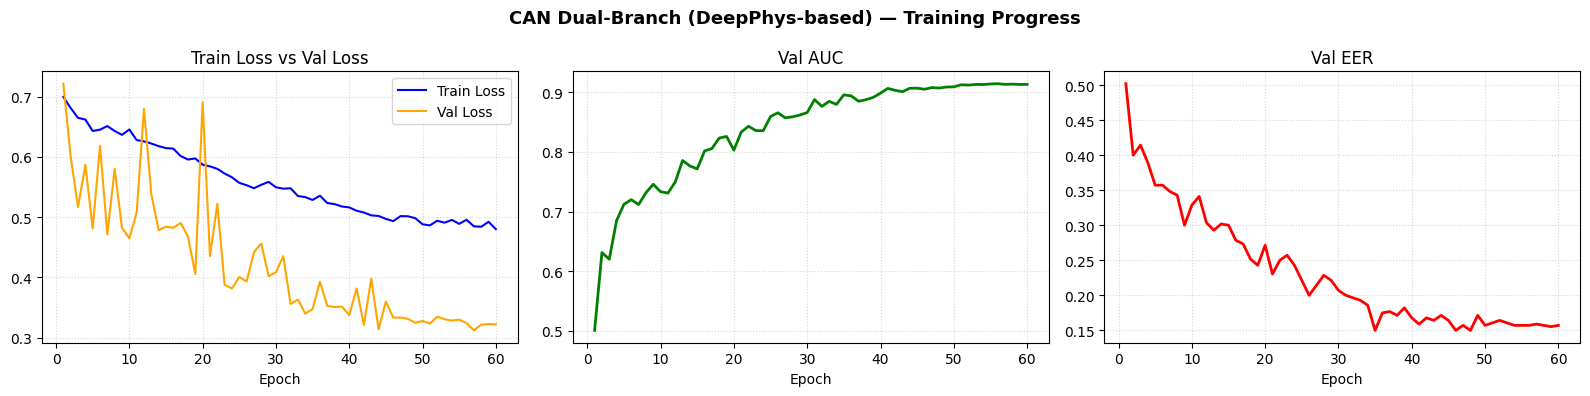

Chênh lệch val_loss - train_loss ở epoch cuối: -0.1580


In [9]:
import matplotlib.pyplot as plt

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", color="blue")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss", color="orange")
axes[0].set_title("Train Loss vs Val Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="green", linewidth=2)
axes[1].set_title("Val AUC"); axes[1].set_xlabel("Epoch")
axes[1].grid(True, linestyle=':', alpha=0.5)

axes[2].plot(hist_df["epoch"], hist_df["val_eer"], color="red", linewidth=2)
axes[2].set_title("Val EER"); axes[2].set_xlabel("Epoch")
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.suptitle("CAN Dual-Branch (DeepPhys-based) — Training Progress", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()

gap = hist_df["val_loss"].iloc[-1] - hist_df["train_loss"].iloc[-1]
print(f"Chênh lệch val_loss - train_loss ở epoch cuối: {gap:+.4f}")


## 10. ⚠️ Lưu kết quả & bước tiếp theo

**Save Version → Save & Run All (Commit)** → tab **Output** → **New Dataset** để lưu:
- `rppg_can_best.pth` — checkpoint tốt nhất (dùng để ghép fusion model)
- `train_history.csv` — lịch sử huấn luyện
- `test_results_intra.csv` — kết quả test
- `auc_breakdown_by_method.csv` — AUC/EER theo từng phương pháp fake
- `training_curves.png` — biểu đồ

**Bước tiếp theo:** dùng `rppg_can_best.pth` cùng với `spatial_transformer_best.pth`
để xây dựng **DF-FusionModel** (kết hợp Spatial + rPPG qua CAN).
